# Bias Detection with **MSD**

**Maximum Subgroup Discrepancy (MSD)** measures how far two distributions differ inside their worst-case protected subgroup.

* Two datasets are **close** iff every subgroup defined by the
  protected attributes behaves similarly.  
* MSD keeps that worst-case guarantee **and** needs only **O(# protected features)**
  samples (linear) instead of the exponential sample sizes required by
  classical distances such as Total Variation or Wasserstein.

**Why this matters**: MSD uncovers hidden *intersectional* bias that
  marginal metrics miss **and** returns the exact logical rule describing the
  most disadvantaged group.


## Demo dataset  `01_data.csv`

| Column   | Type & values                                                 | Role            |
|----------|--------------------------------------------------------------|-----------------|
| `Race`   | categorical {Green, Blue, Purple}                            | protected       |
| `Age`    | categorical {0-18, 18-30, 30-45, 45-60, 60+}                 | protected       |
| `Target` | binary {0, 1} (e.g. loan approval)                           | outcome tested  |

The toy data are crafted so that global **demographic parity** holds  
(each race × age bucket has the same mean `Target`) **but young Blue people are
severely under-served**.  
MSD should discover exactly that subgroup.

<img src="./images/motivation_MSD.png" width="600">

In [1]:
dataset_path = "../data/01_data.csv"

target = "Target"
protected_list = ["Race", "Age"]

In [2]:
# from humancompatible.detect import most_biased_subgroup_csv, evaluate_biased_subgroup_csv
from humancompatible.detect import detect_and_score  # Combines both functions above

import logging
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")


rule, msd_val = detect_and_score(
    csv_path=dataset_path,
    target_col=target,
    protected_list=protected_list,
    method="MSD",
)

[INFO] Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
[INFO] RUN!
[WARNING] Vector y has dtype int64 instead of bool. Assuming value for True is 1.


In [3]:
print(f"MSD value: {msd_val:.3f}")
print(f"Rule: {rule}")

MSD value: 0.111
Rule: [(0, Bin(<humancompatible.detect.data_handler.features.Categorical.Categorical object at 0x000001E97FF78AD0>, <Operation.EQ: '='>, 'Blue')), (1, Bin(<humancompatible.detect.data_handler.features.Categorical.Categorical object at 0x000001E928034B90>, <Operation.EQ: '='>, '0-18'))]


## Interpreting the rule

`rule` is a list of pairs of original feature indices (columns) and `Bin` objects, that describe the condition applied to a given feature value. The bins can be easily printed: 

In [4]:
print("The group is: " + " AND ".join(str(r) for _, r in rule))

The group is: Race = Blue AND Age = 0-18


We can also use the `Bin` objects to simply evaluate samples using the rule.

In [5]:
import numpy as np

samples = np.array([["Blue", "0-18"], ["Green", "0-18"], ["Blue", "40-60"]])

in_group = np.ones(samples.shape[0], dtype=bool)
for i, r in rule:
    in_group &= r.evaluate(samples[:,i])
in_group

array([ True, False, False])

## Conclusion

**MSD score**  
  The computed MSD of **0.111…** tells us that the subgroup  
  **`Race = Blue AND Age = 0–18`**  
  appears **11.1 percentage points more often** among the negative outcomes than among the positive outcomes.

**What does this mean**  
  In this toy dataset, "Blue young persons" are the most disproportionally-served subgroup, as evident from the image.

# Bias Detection with $l_\infty$

With the **Subsampled** $l_\infty$ **norm**, we can quickly check the bias for a particular subgroup.

**Why this matters**: This comes in handy for cases in which a predetermined bias threshold has to be checked to comply with legal standards.

## Demo dataset  `01_data+gender.csv`

| Column   | Type & values                                                 | Role            |
|----------|--------------------------------------------------------------|-----------------|
| `Gender` | categorical {M,F}                                            | protected       |
| `Race`   | categorical {Green, Blue, Purple}                            | protected       |
| `Age`    | categorical {0-18, 18-30, 30-45, 45-60, 60+}                 | protected       |
| `Target` | binary {0, 1} (e.g. loan approval)                           | outcome tested  |

The new attribute *Gender* has been added in a way that mantains the previous **demographic parity**

In [1]:
dataset_path = "../data/01_data+gender.csv"

target = "Target"
protected_list = ["Race", "Age", "Gender"]

> ### Note: This notebook uses small helper utilities from examples/supports/.

In [2]:
try:
    from supports.linf_utils import heatmap, annotate_heatmap, get_heatmap_array, load_heatmap
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("""
	First, ensure you have installed the addition to the repository with the command:
        python -m pip install "humancompatible-detect[examples]"

    Missing example helper module: supports/linf_utils.py

    This notebook expects the layout:
	./supports/
		linf_utils.py

    Fix (choose one):
      1) Download the full repository ZIP and run the notebook from it, or
      2) Copy the 'examples/supports/' folder next to the notebooks, or
      3) Copy the contents of linf_utils.py into the notebook.

    Reference:
      https://github.com/humancompatible/detect/tree/main/examples/supports
    """)


Internally, $l_\infty$ compares two normalised histograms, represented here as heatmaps:

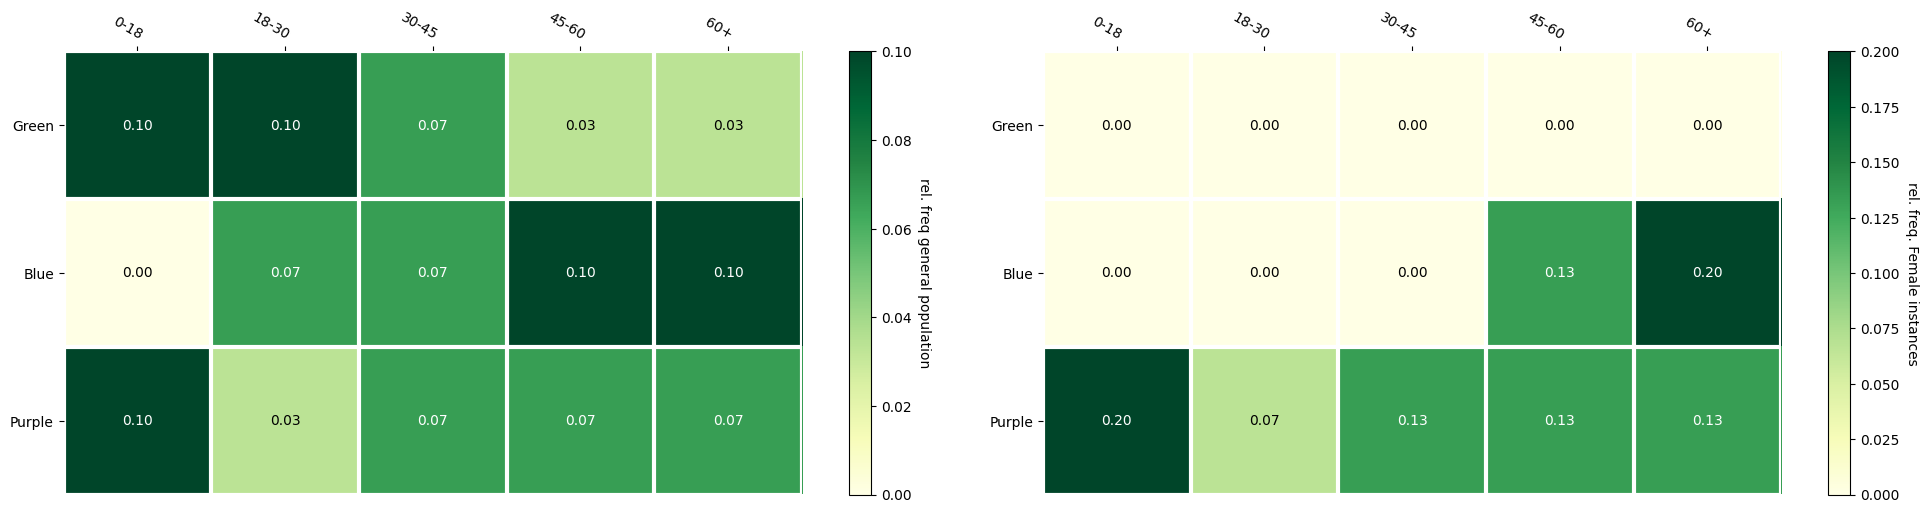

In [3]:
load_heatmap(csv_path=dataset_path,
    target_col=target,
    protected_list=protected_list,
    feature_involved='Gender',
    subgroup_to_check='F')

Above, we can compare visually the occurrences of the positive outcome in the different subgroups from the *Age* and *Race* fields, for the two possible values of the *Gender* attribute.

To run the method, we input the group (`subgroup_to_check`) and the corresponding feature (`feature_involved`) that we want to check, along with the desired bias level (`delta`) to be checked.

In [21]:
from humancompatible.detect import evaluate_biased_subgroup_csv

is_biased = evaluate_biased_subgroup_csv(
    csv_path=dataset_path,
    target_col=target,
    protected_list=protected_list,
    method="l_inf",
    method_kwargs={'delta': .125, 'feature_involved': 'Gender', 'subgroup_to_check': 'F'}
)

print("Is the most impactful subgroup biased?", is_biased)

Is the most impactful subgroup biased? True
